## Аналитика. Начальный уровень

Перед вами стоит задача – подготовить аналитический отчет для HR-отдела. На основании проведенной аналитики предполагается составить рекомендации для отдела кадров по стратегии набора персонала, а также по взаимодействию с уже имеющимися сотрудниками.
<br><br> В базе данных лежит набор таблиц, которые содержат данные о сотрудниках вымышленной компании.
Сделайте обзор штата сотрудников компании. Составьте набор предметов исследования, а затем проверьте их на данных. Вся аналитика должна быть выполена с помощью SQL. Впоследствии данные можно визуализировать, однако финальные датафреймы для графиков также должны быть подготовлены с помощью SQL. <br>

# 1. Выгрузка и подготовка данных

In [1]:
import sqlalchemy
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
engine = sqlalchemy.create_engine(conn)
connect = engine.connect()

In [4]:
# Взглянем на таблицу hr_dataset
df = pd.read_sql_table('hr_dataset', con=engine, index_col='id')
pd.set_option('display.max_columns', None)
df

,Employee Name,Employee Number,marriedid,maritalstatusid,genderid,empstatus_id,deptid,perf_scoreid,age,Pay Rate,state,zip,dob,sex,maritaldesc,citizendesc,Hispanic/Latino,racedesc,Date of Hire,Days Employed,Date of Termination,Reason For Term,Employment Status,department,position,Manager Name,Employee Source,Performance Score
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,"Brown, Mia",1103024456,1,1,0,1,1,3,30,28.50,MA,1450,1987-11-24,Female,Married,US Citizen,No,Black or African American,2008-10-27,3317,NaT,N/A - still employed,Active,Admin Offices,Accountant I,Brandon R. LeBlanc,Diversity Job Fair,Fully Meets
2,"LaRotonda, William",1106026572,0,2,1,1,1,3,34,23.00,MA,1460,1984-04-26,Male,Divorced,US Citizen,No,Black or African American,2014-01-06,1420,NaT,N/A - still employed,Active,Admin Offices,Accountant I,Brandon R. LeBlanc,Website Banner Ads,Fully Meets
3,"Steans, Tyrone",1302053333,0,0,1,1,1,3,31,29.00,MA,2703,1986-09-01,Male,Single,US Citizen,No,White,2014-09-29,1154,NaT,N/A - still employed,Active,Admin Offices,Accountant I,Brandon R. LeBlanc,Internet Search,Fully Meets
4,"Howard, Estelle",1211050782,1,1,0,1,1,9,32,21.50,MA,2170,1985-09-16,Female,Married,US Citizen,No,White,2015-02-16,58,2015-04-15,N/A - still employed,Active,Admin Offices,Administrative Assistant,Brandon R. LeBlanc,Pay Per Click - Google,N/A- too early to review
5,"Singh, Nan",1307059817,0,0,0,1,1,9,30,16.56,MA,2330,1988-05-19,Female,Single,US Citizen,No,White,2015-05-01,940,NaT,N/A - still employed,Active,Admin Offices,Administrative Assistant,Brandon R. LeBlanc,Website Banner Ads,N/A- too early to review
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Navathe, Kurt",1009919960,0,0,1,1,3,3,48,52.25,MA,2056,1970-04-25,Male,Single,US Citizen,No,Asian,2017-02-10,289,NaT,N/A - still employed,Active,IT/IS,Senior BI Developer,Brian Champaigne,Indeed,Fully Meets
307,"Wang, Charlie",1009919970,0,0,1,1,3,3,36,51.00,MA,1887,1981-07-08,Male,Single,US Citizen,No,Asian,2017-02-15,284,NaT,N/A - still employed,Active,IT/IS,Senior BI Developer,Brian Champaigne,Indeed,Fully Meets
308,"Smith, Jason",1009919980,0,0,1,1,3,3,34,46.00,MA,2045,1983-09-04,Male,Single,US Citizen,No,White,2017-02-15,284,NaT,N/A - still employed,Active,IT/IS,BI Developer,Brian Champaigne,Indeed,Fully Meets


## 1.1 Описание таблицы hr_dataset

Данные таблицы представляют собой комплексную HR-базу с информацией о сотрудниках, их демографических характеристиках, рабочих показателях и истории трудоустройства в компании.

`hr_dataset` содержит следующие значения: <br><br>

**Основные идентификаторы**<br><br>
&nbsp;&nbsp;&nbsp;&nbsp; `id` — Уникальный идентификатор сотрудника, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `Employee Name` —  ФИО сотрудников, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `Employee Number` — Номер сотрудника в системе (уникальные числовые значения). <br> <br>
**Демографические данные**<br><br>
&nbsp;&nbsp;&nbsp;&nbsp; `marriedid` — Идентификатор семейного положения, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `maritalstatusid` — Идентификатор семейного положения:<br>
&nbsp;&nbsp;&nbsp;&nbsp; `maritaldesc` — Детальный идентификатор семейного положения:<br>
- Married (Женат/Замужем)
- Divorced (В разводе)
- Single (Холост/Не замужем)
- Separated (В раздельном проживании)
- Widowed (Вдовец/Вдова),
<br><br>
&nbsp;&nbsp;&nbsp;&nbsp; `genderid` — Идентификатор пола, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `sex` — Пол: Male (Мужской), Female (Женский), <br>
&nbsp;&nbsp;&nbsp;&nbsp; `age` — Возраст сотрудников, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `dob` — Дата рождения, <br> 
&nbsp;&nbsp;&nbsp;&nbsp; `Hispanic/Latino` — Принадлежность к латиноамериканской этнической группе, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `racedesc` — Раса/этническая принадлежность:<br> 
- Black or African American
- White
- Asian
- Two or more races
- Hispanic
- American Indian or Alaska Native,
<br><br>
&nbsp;&nbsp;&nbsp;&nbsp; `citizendesc` — Гражданство<br>
- US Citizen
- Eligible NonCitizen
- Non-Citizen,
<br><br>
**Рабочие данные**<br><br>
&nbsp;&nbsp;&nbsp;&nbsp; `empstatus_id` — Идентификатор статуса работы, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `Employment Status` — Статус работы: <br>
- Active (Активный)
- Voluntarily Terminated (Уволился по собственному желанию)
- Terminated for Cause (Уволен по причине)
- Leave of Absence (В отпуске)
- Future Start (Будущий старт)
<br><br>
&nbsp;&nbsp;&nbsp;&nbsp; `deptid` — Идентификатор отдела, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `department` — Название отдела, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `position` — Должность, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `Manager Name` — Имя руководителя, <br><br>

**Финансовые и локационные данные**<br><br>

&nbsp;&nbsp;&nbsp;&nbsp; `Pay Rate` — Почасовая ставка оплаты, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `state` — Штат, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `zip` — Почтовый индекс, <br><br>

**Даты трудоустройства**<br><br>

&nbsp;&nbsp;&nbsp;&nbsp; `Date of Hire` — Дата найма, <br> 
&nbsp;&nbsp;&nbsp;&nbsp; `Date of Termination` — Дата увольнения (NaT для действующих сотрудников), <br>
&nbsp;&nbsp;&nbsp;&nbsp; `Days Employed` — Количество дней работы в компании, <br><br>

**Источники найма и производительность**<br><br>

&nbsp;&nbsp;&nbsp;&nbsp; `Employee Source` — Источник найма, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `Reason For Term` — Причина увольнения.<br>
&nbsp;&nbsp;&nbsp;&nbsp; `perf_scoreid` — Идентификатор оценки производительности, <br>
&nbsp;&nbsp;&nbsp;&nbsp; `Performance Score` — Оценка производительности: <br>
- Fully Meets (Полностью соответствует)
- N/A- too early to review (Слишком рано для оценки)
- 90-day meets (Соответствует по итогам 90 дней)
- Exceptional (Исключительный)
- Needs Improvement (Требует улучшений)
- Exceeds (Превышает ожидания)
- PIP (План по улучшению производительности)


## 1.2 Подготовка данных для дальнейшей работы

После первого взгляда на данные становится очевидно, что некоторые данные в таблице требуется преобразовать:
- Колонка **zip(Почтовый индекс)** не представляет интереса.
- Колонка **perf_scoreid(Идентификатор оценки производительности)** - идентификатор значений Perfomance Score, но не представляет из себя числовую оценку, можно удалить.
- Колонка **Perfomance Score(Оценка производительности)** требует числового представления в виде бальной системы, поэтому создадим колонку **perf_score_rank**, который будет определять баллы по следующей схеме: 0 - "N/A- too early to review", 1 - "PIP", "Needs Improvement", 2 - "90-day meets", "Fully Meets", 3 - "Exceeds", "Exceptional"
- Колонку **Hispanic/Latino(Принадлежность к латиноамериканской этнической группе)** нужно привести к числовым значениям. 1 - "Yes", 0 - "No"
- Колонку **Employee Name(ФИО сотрудников)** нужно преобразовать для удобства дальнейшей работы
- Колонку **Pay Rate** преобразуем в **pay_rate_rank** разбитую на три интервала зарплат

In [5]:
# Нашу преобразованную таблицу сохраним в CTE для дальнейшего использования, т.к исходная таблица в БД доступная только для чтения
cte = '''
 WITH hr_data AS (
 SELECT
     REPLACE(CONCAT(TRIM(REGEXP_REPLACE("Employee Name", '^.*?,', '')), ' ', TRIM(REGEXP_REPLACE("Employee Name", ',.*$', ''))), '  ', ' ') AS "employee_name",
     marriedid, maritalstatusid, maritaldesc, genderid, sex, age, dob,
     CASE 
        WHEN LOWER("Hispanic/Latino") like 'yes' THEN 1
        ELSE 0
     END AS hispanic_latino,
     racedesc, citizendesc, empstatus_id, "Employment Status" AS "employment_status", deptid, department, position, 
     REPLACE("Manager Name", '.', '') AS "manager_name",
     CASE 
         WHEN "Pay Rate" BETWEEN 14 AND 36 THEN 1
         WHEN "Pay Rate" BETWEEN 37 AND 58 THEN 2
         WHEN "Pay Rate" BETWEEN 59 AND 80 THEN 3
     END AS pay_rate_rank,
     state, "Date of Hire" AS "date_of_hire", "Date of Termination" AS "date_of_termination", 
     "Days Employed" AS "days_employed", "Employee Source" AS "employee_source", "Reason For Term" AS "reason_fo_term", 
     "Performance Score" AS "performance_score", 
     CASE 
         WHEN "Performance Score" IN ('N/A- too early to review') THEN 0
         WHEN "Performance Score" IN ('PIP', 'Needs Improvement') THEN 1
         WHEN "Performance Score" IN ('90-day meets', 'Fully Meets') THEN 2
         WHEN "Performance Score" IN ('Exceeds', 'Exceptional') THEN 3
     END AS perf_score_rank
 FROM hr_dataset
 )
'''
# Пишем запрос чтобы вывести итоговую таблицу
query = ''' SELECT * FROM hr_data'''
main = pd.read_sql_query(sql=(cte+query), con=engine)
connect.close()
main

,employee_name,marriedid,maritalstatusid,maritaldesc,genderid,sex,age,dob,hispanic_latino,racedesc,citizendesc,empstatus_id,employment_status,deptid,department,position,manager_name,pay_rate_rank,state,date_of_hire,date_of_termination,days_employed,employee_source,reason_fo_term,performance_score,perf_score_rank
0,Mia Brown,1,1,Married,0,Female,30,1987-11-24,0,Black or African American,US Citizen,1,Active,1,Admin Offices,Accountant I,Brandon R LeBlanc,1.0,MA,2008-10-27,None,3317,Diversity Job Fair,N/A - still employed,Fully Meets,2
1,William LaRotonda,0,2,Divorced,1,Male,34,1984-04-26,0,Black or African American,US Citizen,1,Active,1,Admin Offices,Accountant I,Brandon R LeBlanc,1.0,MA,2014-01-06,None,1420,Website Banner Ads,N/A - still employed,Fully Meets,2
2,Tyrone Steans,0,0,Single,1,Male,31,1986-09-01,0,White,US Citizen,1,Active,1,Admin Offices,Accountant I,Brandon R LeBlanc,1.0,MA,2014-09-29,None,1154,Internet Search,N/A - still employed,Fully Meets,2
3,Estelle Howard,1,1,Married,0,Female,32,1985-09-16,0,White,US Citizen,1,Active,1,Admin Offices,Administrative Assistant,Brandon R LeBlanc,1.0,MA,2015-02-16,2015-04-15,58,Pay Per Click - Google,N/A - still employed,N/A- too early to review,0
4,Nan Singh,0,0,Single,0,Female,30,1988-05-19,0,White,US Citizen,1,Active,1,Admin Offices,Administrative Assistant,Brandon R LeBlanc,1.0,MA,2015-05-01,None,940,Website Banner Ads,N/A - still employed,N/A- too early to review,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,Kurt Navathe,0,0,Single,1,Male,48,1970-04-25,0,Asian,US Citizen,1,Active,3,IT/IS,Senior BI Developer,Brian Champaigne,2.0,MA,2017-02-10,None,289,Indeed,N/A - still employed,Fully Meets,2
306,Charlie Wang,0,0,Single,1,Male,36,1981-07-08,0,Asian,US Citizen,1,Active,3,IT/IS,Senior BI Developer,Brian Champaigne,2.0,MA,2017-02-15,None,284,Indeed,N/A - still employed,Fully Meets,2
307,Jason Smith,0,0,Single,1,Male,34,1983-09-04,0,White,US Citizen,1,Active,3,IT/IS,BI Developer,Brian Champaigne,2.0,MA,2017-02-15,None,284,Indeed,N/A - still employed,Fully Meets,2
308,Matthew Westinghouse,1,1,Married,1,Male,30,1987-10-24,0,White,US Citizen,1,Active,3,IT/IS,BI Developer,Brian Champaigne,2.0,MA,2017-04-20,None,220,Indeed,N/A - still employed,Fully Meets,2


## 1.3 Посмотрим наиболее очевидные зависимости данных

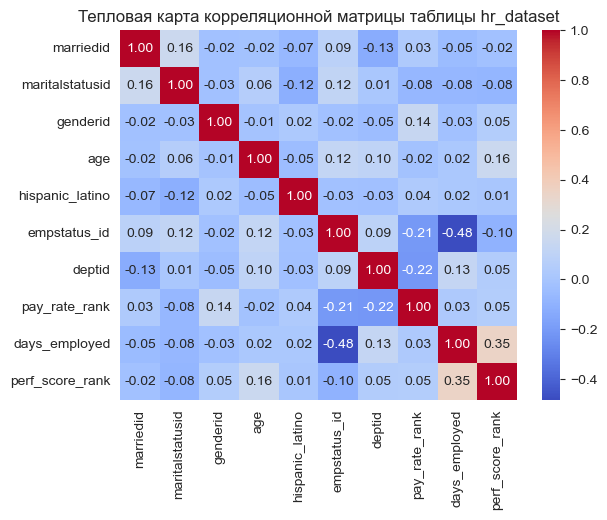

In [6]:
# Построим тепловую карту корреляции значений таблицы
sns.heatmap(data=main.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Тепловая карта корреляционной матрицы таблицы hr_dataset');

## 1.3.1 Зависимость между продолжительностью работы в компании и статусом сотрудника

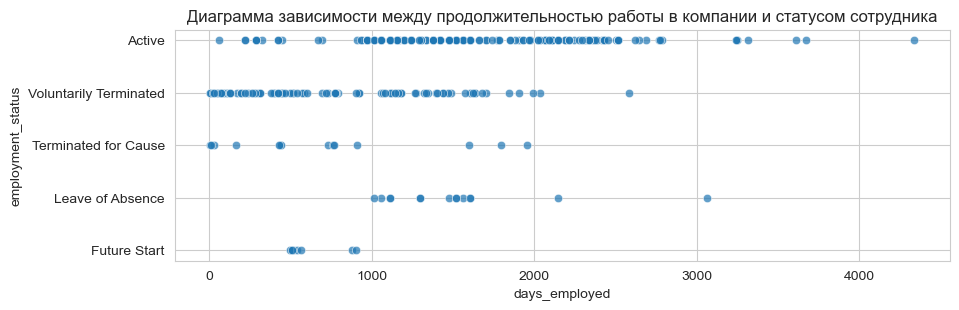

In [7]:
plt.figure(figsize=(10,3))
sns.scatterplot(data=main, x='days_employed', y='employment_status', alpha=0.7)
plt.title('Диаграмма зависимости между продолжительностью работы в компании и статусом сотрудника');

## 1.3.2 Зависимости между продолжительностью работы в компании и оценкой производительности

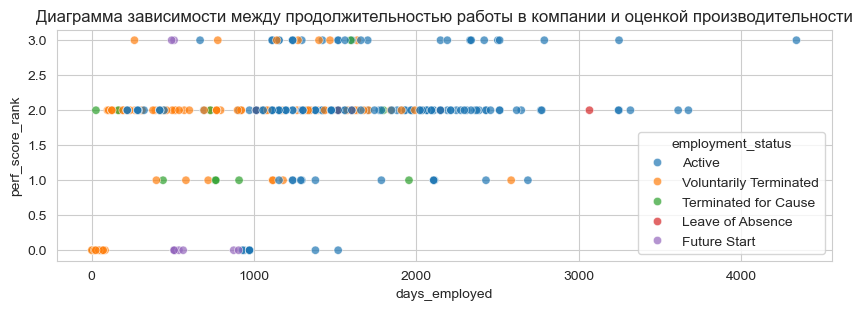

In [8]:
plt.figure(figsize=(10,3))
sns.scatterplot(data=main, x='days_employed', y='perf_score_rank', hue='employment_status', alpha=0.7)
plt.title('Диаграмма зависимости между продолжительностью работы в компании и оценкой производительности');

# 2. Исследование данных

## 2.1 Влияние источника найма на оценку производительности

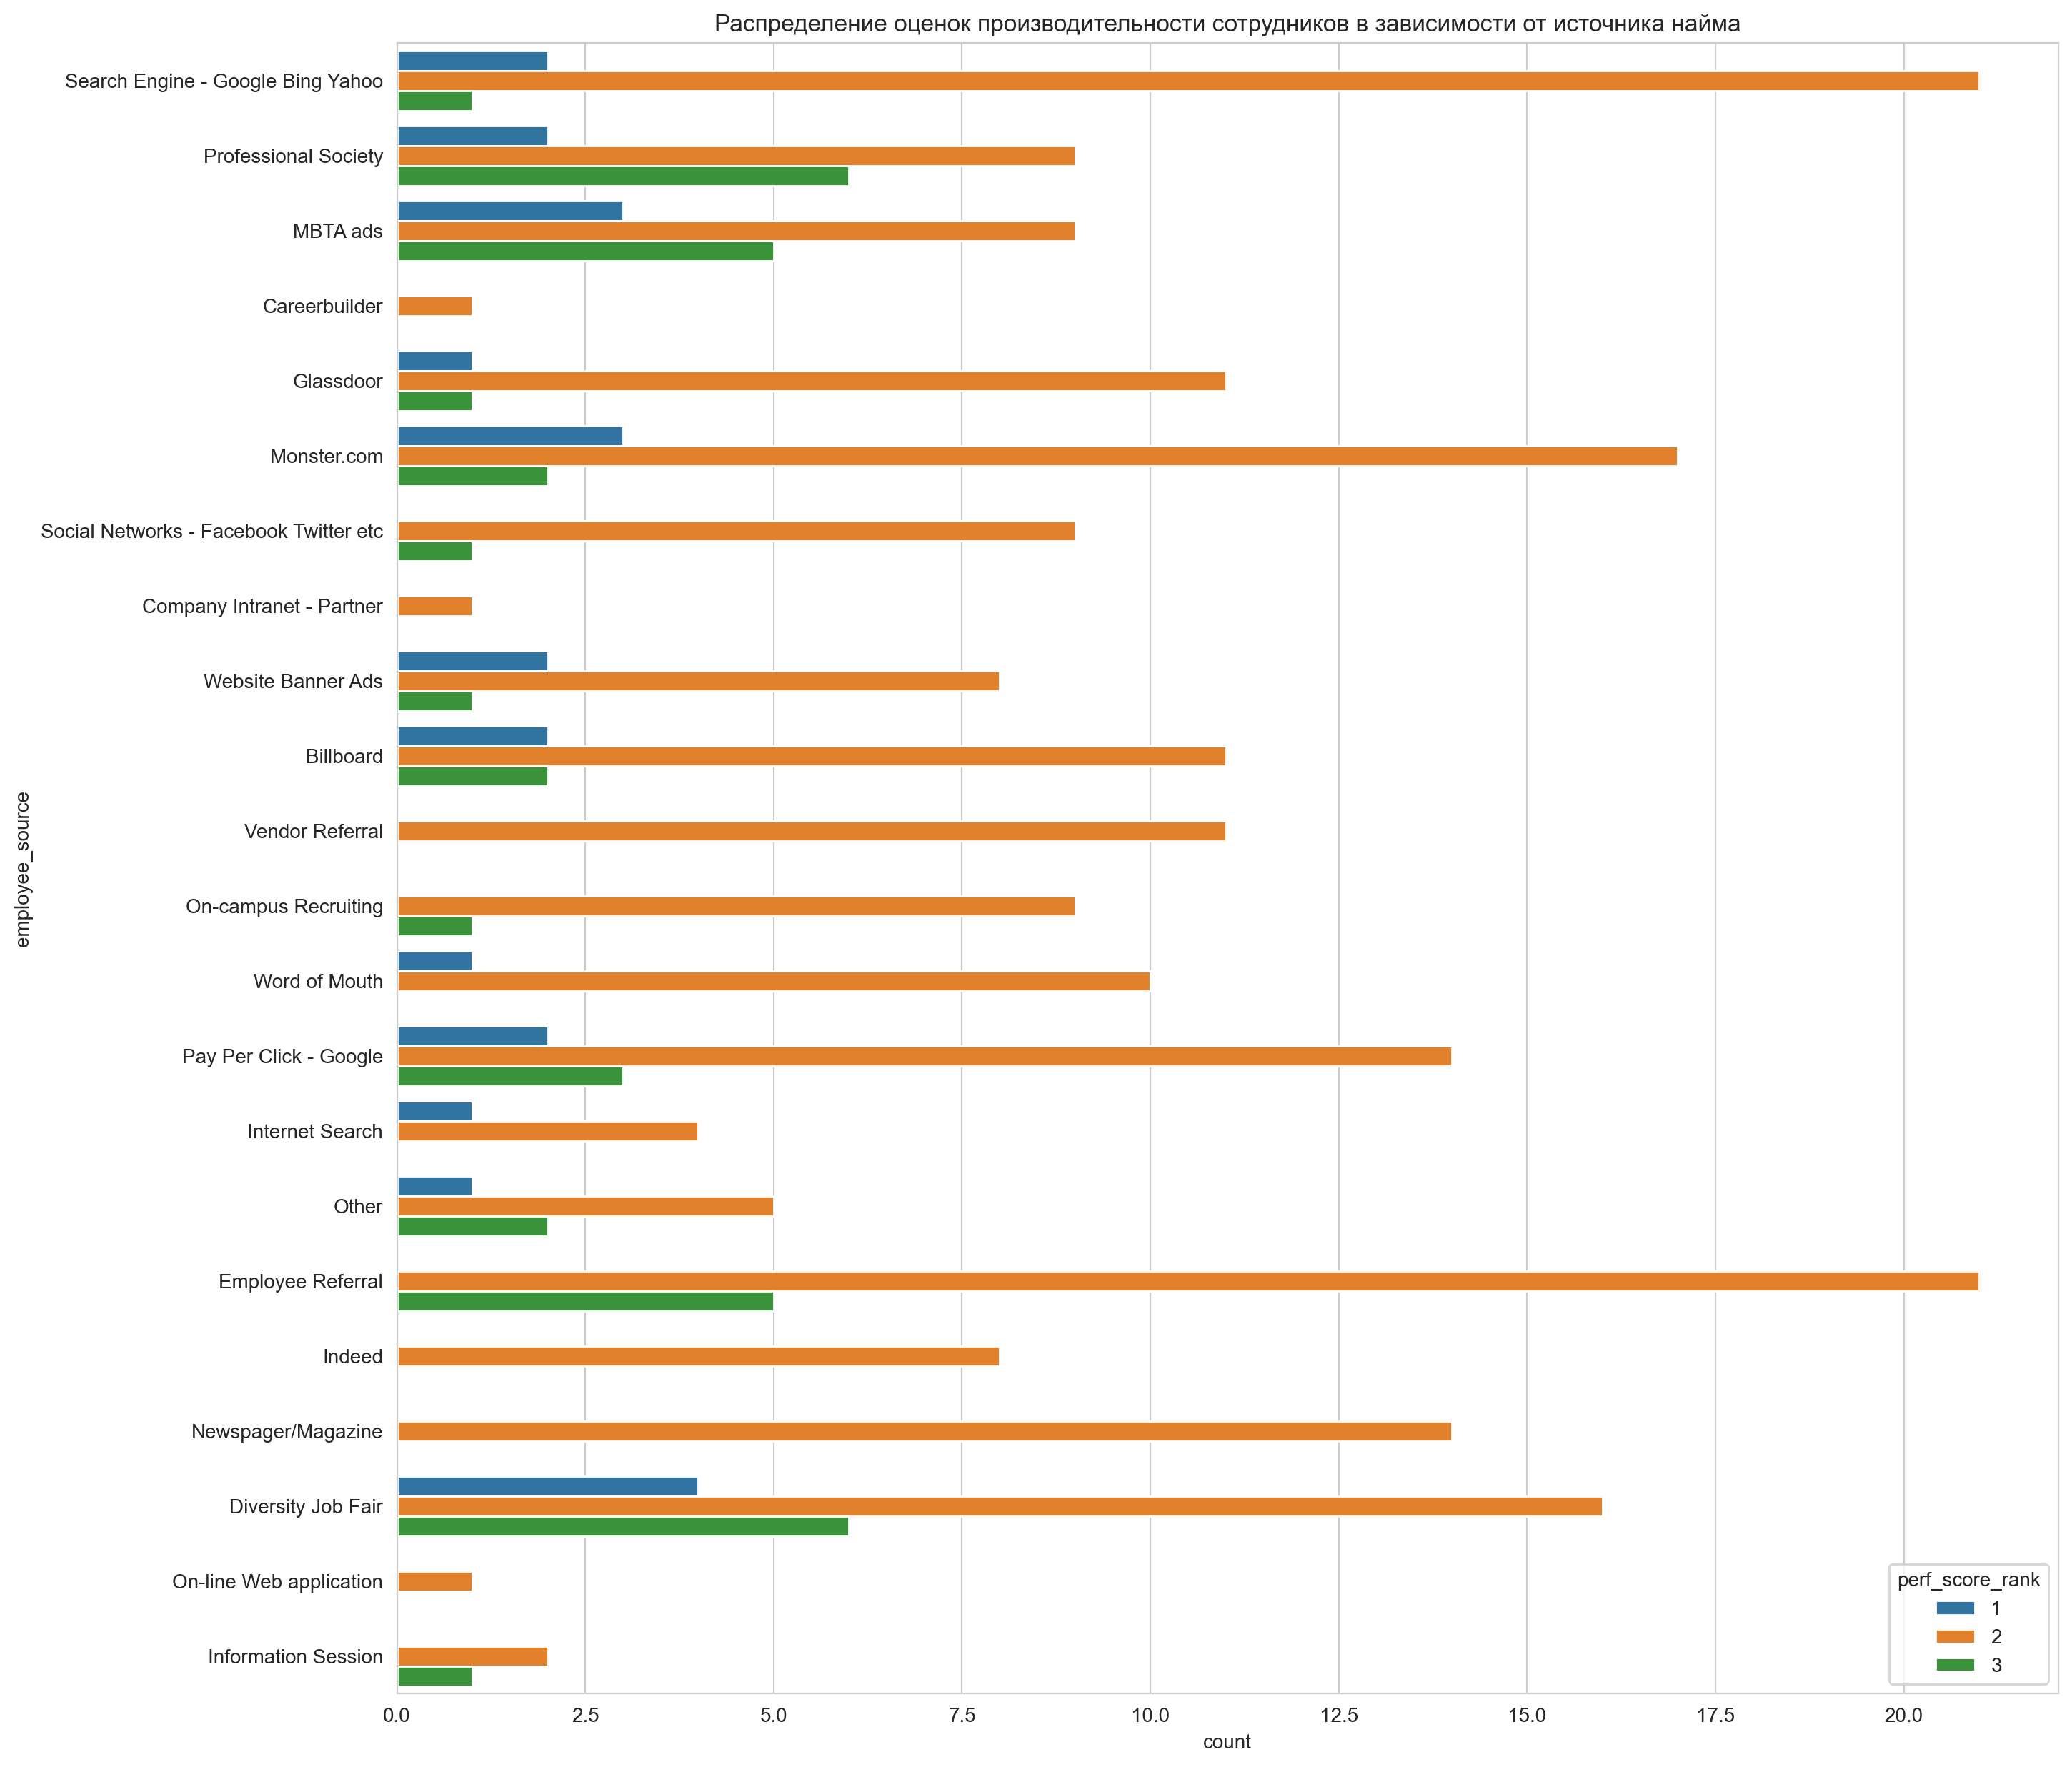

In [9]:
# выгрузим данных из таблицы в датафрейм
query = '''
    SELECT employee_source, perf_score_rank, COUNT(*)
    FROM hr_data
    WHERE perf_score_rank >= 1
    GROUP BY employee_source, perf_score_rank
    '''
df1 = pd.read_sql_query(sql=(cte+query), con=engine)
connect.close()

# Визуализируем полученные данные
plt.figure(figsize=(15,15), dpi=200)
sns.barplot(data=df1, y='employee_source', x='count', orient='y', hue='perf_score_rank', palette='tab10')
plt.title('Распределение оценок производительности сотрудников в зависимости от источника найма');

## 2.2 Влияние семейного положения на оценку производительности

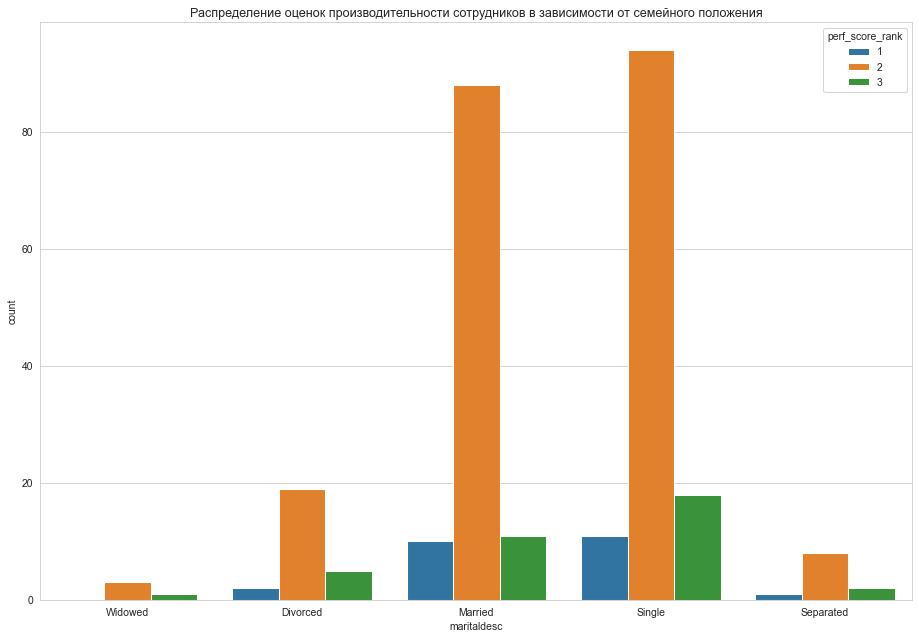

In [10]:
# выгрузим данных из таблицы в датафрейм
query = '''
    SELECT maritaldesc, perf_score_rank, COUNT(*)
    FROM hr_data
    WHERE perf_score_rank >= 1
    GROUP BY maritaldesc, perf_score_rank
    '''
df2 = pd.read_sql_query(sql=(cte+query), con=engine)
connect.close()

# Визуализируем полученные данные
plt.figure(figsize=(15,10), dpi=75)
sns.barplot(data=df2, x='maritaldesc', y='count', hue='perf_score_rank', palette='tab10')
plt.title('Распределение оценок производительности сотрудников в зависимости от семейного положения');

## 2.3 Распределение оценок производительности сотрудников в зависимости от подразделения

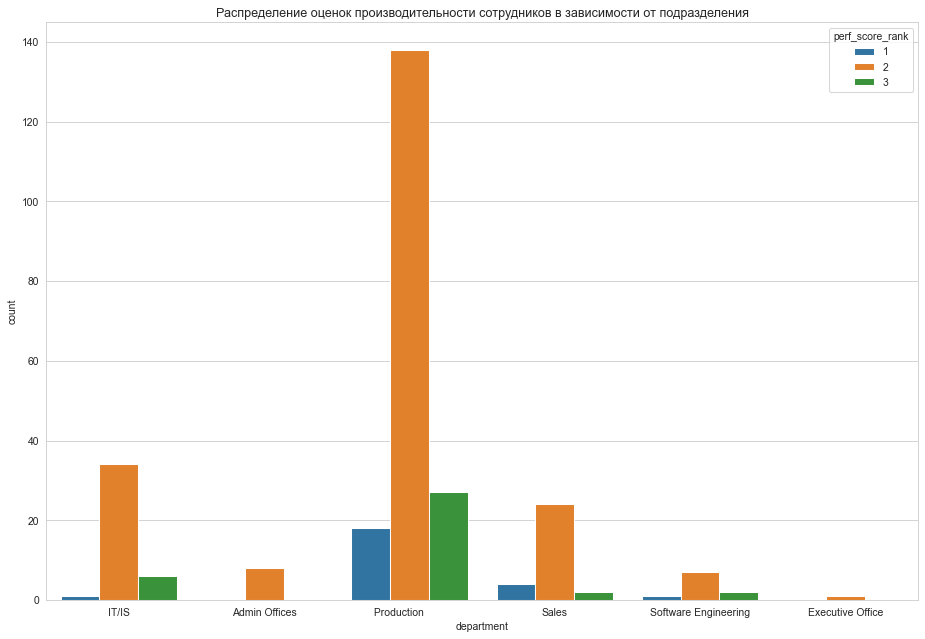

In [11]:
# выгрузим данных из таблицы в датафрейм
query = '''
    SELECT department, perf_score_rank, COUNT(*)
    FROM hr_data
    WHERE perf_score_rank >= 1
    GROUP BY department, perf_score_rank
    '''
df2 = pd.read_sql_query(sql=(cte+query), con=engine)
connect.close()

# Визуализируем полученные данные
plt.figure(figsize=(15,10), dpi=75)
sns.barplot(data=df2, x='department', y='count', hue='perf_score_rank', palette='tab10')
plt.title('Распределение оценок производительности сотрудников в зависимости от подразделения');

## 2.4 Зависимость между продолжительностью работы в компании и семейным положением сотрудника

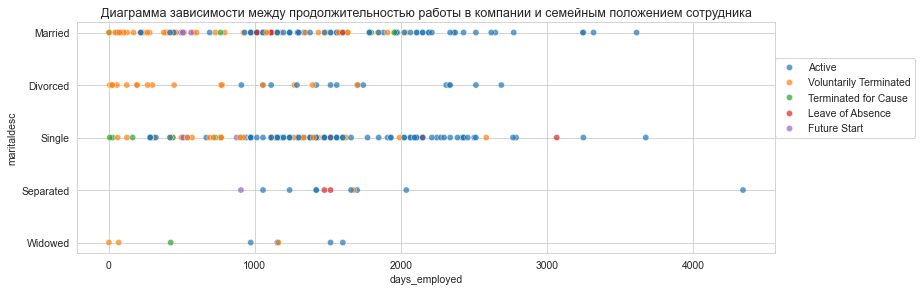

In [12]:
plt.figure(figsize=(12,4), dpi=75)
sns.scatterplot(data=main, x='days_employed', y='maritaldesc', hue='employment_status', alpha=0.7)
plt.title('Диаграмма зависимости между продолжительностью работы в компании и семейным положением сотрудника')
plt.legend(loc=(1,0.5));

## 2.5 Зависимость между продолжительностью работы в компании и возрастом сотрудника

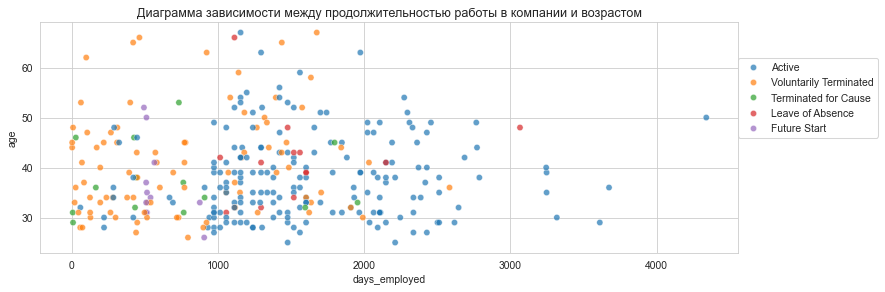

In [13]:
plt.figure(figsize=(12,4), dpi=75)
sns.scatterplot(data=main, x='days_employed', y='age', hue='employment_status', alpha=0.7)
plt.title('Диаграмма зависимости между продолжительностью работы в компании и возрастом')
plt.legend(loc=(1,0.5));

# 3. Итоговый вывод

1. Ключевые выводы из анализа данных

На основе предоставленной информации можно сделать следующие ключевые выводы:

· Возрастной состав: В компании преобладают сотрудники в возрасте от 30 до 50 лет с опытом работы от 3 до 5,5 лет (1000-2000 дней). Именно эта группа демонстрирует наибольшую лояльность и продолжительность работы.
· Семейное положение: Сотрудники, состоящие в браке или холостые, составляют костяк компании и показывают более высокую продолжительность работы по сравнению с разведенными, вдовцами и т.д. При этом холостые сотрудники демонстрируют лучшее соотношение высокой и низкой производительности.
· Производительность: Большинство сотрудников соответствуют требованиям, однако основные "зоны риска" по низкой производительности сосредоточены в отделе продаж.
· Эффективность каналов найма: Наиболее качественных сотрудников приносят реферальные программы и "точечные" каналы (профобщества, вузы, соцсети). Массовые и безличные каналы рекламы и поиска показывают низкую эффективность.

---

2. Рекомендации для стратегии набора персонала

Приоритет 1: Сфокусироваться на наиболее эффективных каналах найма.

· Развивать программу рефералов (Employee Referral): Сделать ее ключевым источником кандидатов. Пересмотреть и повысить бонусы за успешные рекомендации, активно продвигать программу внутри компании.
· Усилить работу с профессиональными сообществами и вузами: Участвовать в профильных конференциях, организовывать стажировки и карьерные мероприятия в вузах (On-campus Recruiting). Это позволит привлекать мотивированных специалистов.
· Использовать таргетированный рекрутинг в социальных сетях: Активно использовать LinkedIn для поиска профессионалов, а также Facebook и Twitter для продвижения employer brand и вакансий в менее формальной обстановке.

Приоритет 2: Снизить зависимость от неэффективных каналов.

· Прекратить или значительно сократить инвестиции в: баннерную рекламу на сайтах, рекламу на билбордах, размещение вакансий на агрегаторе Monster.com.
· Пересмотреть стратегию SEO-рекрутинга: Поисковые системы (Google, Яндекс) и общие интернет-поиски привлекают большой, но некачественный поток кандидатов. Следует оптимизировать этот канал за счет более строгих фильтров в описаниях вакансий и целевых landing page.

---

3. Рекомендации по взаимодействию с текущими сотрудниками

Приоритет 1: Провести углубленный анализ и разработать меры для отдела продаж.

· Иницировать детальный аудит процессов, KPI и системы мотивации в отделе продаж для выявления причин низкой производительности.
· Внедрить программу наставничества и дополнительного обучения для сотрудников отдела продаж, показывающих низкие результаты.
· Пересмотреть систему вознаграждения для более четкой связи с результативностью.

Приоритет 2: Улучшить программы удержания и мотивации для ключевых групп.

· Для сотрудников 30-50 лет (ядро компании): Разработать программы долгосрочной мотивации (опционы, планирование карьеры, менторство), чтобы сохранить их лояльность и опыт.
· Для холостых сотрудников: Использовать их высокую производительность как пример. Предложить им участие в проектах с повышенной ответственностью, карьерный рост и возможности для профессионального развития, чтобы удержать их в компании.

Приоритет 3: Активизировать программу рефералов.

· Поскольку рефералы — лучший источник найма, необходимо не только стимулировать их финансово, но и создавать корпоративную культуру, в которой сотрудникам будет приятно и престижно рекомендовать свою компанию.

Заключение:

Проведенный анализ четко указывает на направления для оптимизации HR-стратегии. Смещение фокуса на качественные каналы найма и адресная работа с ключевыми группами текущих сотрудников позволят не только повысить общее качество персонала, но и снизить текучку и увеличить производительность.

